# Suavizado Exponencial

Esta es una de las tecnicas mas usadas en la industria y muy vieja desde hace muchos años mas o menos desde los 50s y estos por lo general son usados como tecnicas que subyacen o que estan por debajo de muchos de los modelos estadisticos usados exitosamente para predecir series de tiempo por lo que es interesante verlos y saber generar como cierta intuicion acerca de estos de como se usan y para que?, tambien veremos el como salen a la luz, teniendo en cuenta que por lo general no suele ser mas que metodos que promedian o generan pesos a observaciones del pasado decayendo exponencialmente a medida que mas viejas son las observaciones...



## Simple Exponential Smoothing (SES)

Es el tipo de suavizado mas simple que existe, este metodo es bueno cuando tenemos una serie de tiempo que no tiene una tendencia clara ni un patron estacional claro, pero hay que tener en cuenta otra cosa, por lo general estos aparecen en diferentes formas como veremos a continuacion:

$$\hat{y}_{T+1|T} = \alpha y_T + (1 - \alpha) \hat{y}_{T|T-1}$$

Donde $0<=\alpha<=1$ es el parametro de suavizado

El parámetro $\alpha$ (alfa) es como una perilla que ajusta tu memoria:

- Si $\alpha$ es alto (cerca de 1): Tienes "memoria a corto plazo". Le das casi toda la importancia a lo que pasó hoy. Si hoy hubo un pico de energía, tu predicción para mañana subirá drásticamente.

- Si $\alpha$ es bajo (cerca de 0): Tienes "mucha memoria histórica". Ignoras los cambios bruscos de hoy y te quedas con el promedio de lo que ha venido pasando hace tiempo.

### ¿Cuándo es el "Rey" y cuándo falla?

- Es perfecto cuando: Los datos son "planos". No hay una tendencia clara hacia arriba o hacia abajo, ni hay ciclos repetitivos (como que siempre suba los lunes). Es ideal para datos que oscilan alrededor de un promedio constante.

- Falla cuando: Hay una tendencia. Si el consumo de energía sube un 5% cada mes, el SES siempre se quedará "atrás", porque no sabe reconocer que las cosas están subiendo sistemáticamente.

Algo curioso del SES es que, como no detecta tendencias ni estacionalidad, su predicción para mañana, para pasado mañana y para dentro de un año es exactamente la misma. A esto se le llama **Prediccion Plana**

$$\hat{y}_{T+h|T} = \hat{y}_{T+1|T}$$

Es como decir: "Como no veo que esto suba ni baje con orden, mi mejor apuesta para cualquier momento del futuro es este promedio ponderado que acabo de calcular".

---

#

## Metodos con Tendencia

### Holt’s linear trend

Este metodo se extendió para permitir la prediccion de datos con tendencia, este metodo tiene por dentro 3 cosas la **Ecuacion de prediccion, y 2 de suavizado (una de nivel y otra de Tendencia)** 

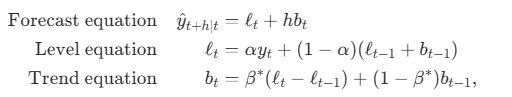

Donde l1 denota una estimacion del nivel de la serie de tiempo en un tiempo t y bt denota una estimacion de la pendiente o tendencia de la serie de tiempo en un tiempo t, alfa es el parametro de suavizado y betha es el parametro de suavizado para la tendencia 

Para intentar entenderlo de una forma mas intuitiva y no tan rigurosa imagina que estás intentando adivinar cuántos juguetes tendrás el próximo mes basándote en lo que ha pasado últimamente.El Método de Holt (o suavizado exponencial doble) es como tener dos lentes especiales para mirar tus datos

- El lente del "Nivel" (¿Dónde estamos ahora?): Este lente mira el valor actual de tus juguetes, dándole más importancia a lo que pasó ayer que a lo que pasó hace un año.

- El lente de la "Tendencia" (¿Hacia dónde vamos?): Este es el toque especial de Holt. Este lente se da cuenta de si cada día estás ganando más juguetes o perdiéndolos. Si ayer tenías 5 y hoy tienes 7, este lente dice: "¡Oye, parece que estamos ganando 2 juguetes por día!".

¿Por qué es mejor que el suavizado simple?

Si usaras el suavizado simple (que solo tiene el primer lente), el modelo pensaría que mañana tendrás lo mismo que hoy Pero el Método de Holt es más inteligente: ve que las cosas están cambiando (hacia arriba o hacia abajo) y usa esa "velocidad" para predecir un valor más alto o más bajo en el futuro


### Damped Trend Methods

(Métodos de tendencia amortiguada) son una extensión del Método de Holt 

Si el Método de Holt que explicamos antes es como un cohete que sube en línea recta para siempre, el Damped Trend es como ponerle un "pequeño paracaídas" o un freno al cohete. Reconoce que, en el mundo real, nada crece o baja para siempre de forma infinita. Con el tiempo, la tendencia tiende a cansarse y a volverse plana.

¿Por qué se usan?

- Problema del Método de Holt: A veces, el método de Holt es "demasiado entusiasta". Si tus ventas subieron un 10% cada mes, el modelo de Holt dirá que en 5 años serás el dueño de toda la galaxia.

- Solución Amortiguada: El método "damped" añade un parámetro (llamado ϕ o phi) que va reduciendo la fuerza de la tendencia a medida que el pronóstico se aleja más en el futuro. Este sobre todo se usa a largo plazo ya que como dijimos anteiormente las tendencias no siempre son constantes 

---

## Metodos con Estacionalidad

En las secciones anteriores de este capítulo sobre suavizado exponencial, hemos explorado cómo modelar series de tiempo que presentan un nivel constante o una tendencia lineal, Sin embargo, en la práctica, muchas de las series de tiempo que enfrentan los analistas y estudiantes —como las ventas mensuales o el flujo de turistas— muestran patrones que se repiten de forma regular en intervalos fijos. Para abordar este desafío, en esta sección introducimos el método de Holt-Winters, una extensión fundamental diseñada para capturar la estacionalidad

El método de Holt-Winters añade un tercer componente a las ecuaciones de nivel y tendencia: el componente estacional. Siguiendo la filosofía de este texto, nos enfocaremos en la aplicación sensible de este método, distinguiendo entre sus dos variantes principales:

- El método aditivo: Apropiado cuando las fluctuaciones estacionales son constantes a lo largo de la serie.

- El método multiplicativo: Recomendado cuando las variaciones estacionales cambian proporcionalmente al nivel de los datos.

### Método de Holt-Winters Aditivo

Se utiliza cuando las variaciones estacionales son constantes a lo largo de la serie, independientemente del nivel de los datos.

$$
\begin{aligned}
l_t &= \alpha(y_t - s_{t-m}) + (1 - \alpha)(l_{t-1} + b_{t-1}) \\
b_t &= \beta^*(l_t - l_{t-1}) + (1 - \beta^*)b_{t-1} \\
s_t &= \gamma(y_t - l_{t-1} - b_{t-1}) + (1 - \gamma)s_{t-m} \\
\hat{y}_{t+h|t} &= l_t + hb_t + s_{t-m+h_m^+}
\end{aligned}
$$

Donde 
- $l_t$ (Level): Representa el nivel base de la serie en el tiempo $t$.

- $b_t$ (Trend): Es el componente de tendencia, que estima la inclinación (crecimiento o decrecimiento) de la serie.

- $s_t$ (Seasonal): Es el componente estacional que captura patrones repetitivos cada $m$ períodos.

- $m$ (Seasonal Period): La longitud del ciclo (ej. $m=4$ para datos trimestrales o $m=12$ para mensuales).

- $\alpha, \beta^*, \gamma$: Son las constantes de suavizado (entre 0 y 1). Valores cercanos a 1 dan más peso a las observaciones recientes, mientras que valores cercanos a 0 dan más peso a la historia pasada.

Imagina que cada primavera salen exactamente 5 flores nuevas, sin importar si el árbol es pequeño o gigante. La cantidad de flores que se suman es siempre la misma. Eso es el método aditivo.


### Método de Holt-Winters Multiplicativo

Se prefiere cuando las variaciones estacionales cambian de forma proporcional al nivel de la serie (si la serie sube, el "pico" estacional se hace más grande).

$$
\begin{aligned}
l_t &= \alpha \left( \frac{y_t}{s_{t-m}} \right) + (1 - \alpha)(l_{t-1} + b_{t-1}) \\
b_t &= \beta^*(l_t - l_{t-1}) + (1 - \beta^*)b_{t-1} \\
s_t &= \gamma \left( \frac{y_t}{l_{t-1} + b_{t-1}} \right) + (1 - \gamma)s_{t-m} \\
\hat{y}_{t+h|t} &= (l_t + hb_t)s_{t-m+h_m^+}
\end{aligned}
$$

Donde:

- $y_t / s_{t-m}$: El nivel se ajusta dividiendo el valor actual por el componente estacional del ciclo anterior.

- $y_t / (l_{t-1} + b_{t-1})$: La actualización de la estacionalidad se calcula como la proporción del error respecto al nivel y tendencia previos.

- Producto final: En la ecuación de pronóstico, el resultado de $(l_t + hb_t)$ se multiplica por el factor estacional $s$, lo que permite capturar magnitudes crecientes en los ciclos.

Imagina que cuando el árbol es pequeño tiene 2 manzanas, pero cuando es el doble de grande, tiene el doble de manzanas (4 manzanas). Aquí, la "estacionalidad" (las manzanas que salen en otoño) no es un número fijo, sino que crece junto con el árbol. Si el árbol es 10 veces más grande, la cosecha es 10 veces más grande.

### Método de Tendencia Amortiguada (Damped Trend)

Este método es una extensión del modelo de Holt. Mientras que el modelo de Holt asume que la tendencia continuará linealmente de forma infinita, el método Damped introduce un parámetro de amortiguación (ϕ) para que la tendencia se aplane con el tiempo.

$$
\begin{aligned}
l_t &= \alpha y_t + (1 - \alpha)(l_{t-1} + \phi b_{t-1}) \\
b_t &= \beta^*(l_t - l_{t-1}) + (1 - \beta^*) \phi b_{t-1} \\
\hat{y}_{t+h|t} &= l_t + \left( \sum_{i=1}^{h} \phi^i \right) b_t
\end{aligned}
$$

Donde:

- Parámetro $\phi$: Actúa como un "freno". Si $\phi = 1$, recuperas el modelo de Holt lineal. Si $\phi < 1$, la pendiente se va aplanando.

- Simplificación de la sumatoria: Para facilitar el cálculo computacional, la sumatoria de la ecuación de pronóstico se suele expresar como una serie geométrica:

$$\hat{y}_{t+h|t} = l_t + \frac{\phi(1 - \phi^h)}{1 - \phi} b_t$$


---

## Taxonomia de Metodos de Suavizado Exponencial

La taxonomía en esta sección organiza los métodos de suavizado exponencial según los componentes que integran la serie de tiempo. Esta clasificación se conoce comúnmente como la taxonomía de Pegels (1969), ampliada posteriormente por Hyndman.

La taxonomía clasifica los métodos basándose en cómo manejan la Tendencia (T) y la Estacionalidad (S). Cada componente puede tener diferentes formas:

1. Componente de Tendencia (T)

- N (None): No hay tendencia (nivel constante).
- A (Additive): Tendencia lineal simple (como el método de Holt).
- $A_d$ (Additive Damped): Tendencia que se amortigua o se "aplana" con el tiempo.

2. Componente de Estacionalidad (S)

- N (None): No hay patrones estacionales.
- A (Additive): La estacionalidad es constante (se suma o resta una cantidad fija).
- M (Multiplicative): La estacionalidad varía proporcionalmente al nivel de los datos (se multiplica por un factor).

Al combinar estos componentes, se genera una matriz que define todos los métodos posibles de suavizado exponencial. Aquí te presento los más comunes:

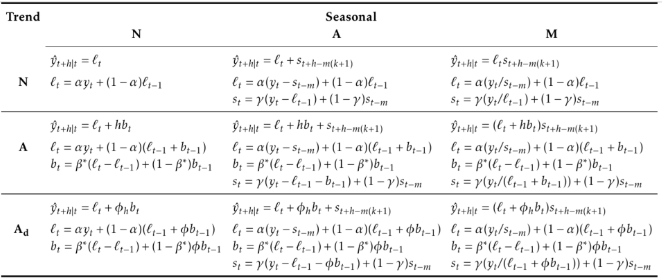


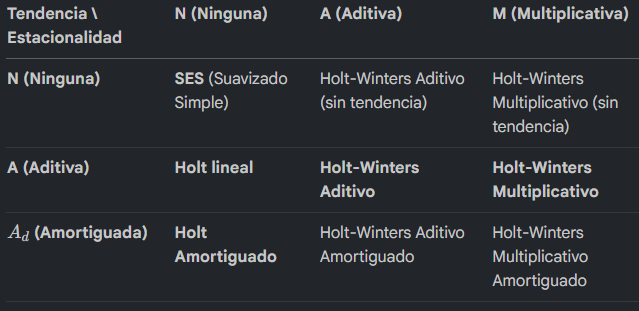

---

## Modelos de Espacio de Estados (ETS) para pronostico

Esta sección convierte los métodos de suavizado en modelos estadísticos reales. El nombre ETS proviene de los tres componentes que el modelo intenta estimar: Error, Trend (Tendencia) y Seasonal (Estacionalidad). La gran innovación es que cada componente puede ser Aditivo (A) o Multiplicativo (M).

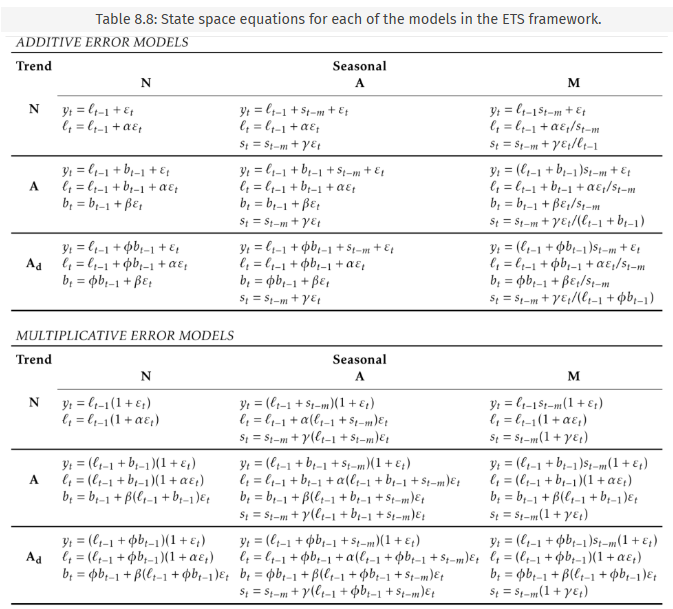

Ahora que ya sabemos que existe una familia grandisima de los modelos estadisticos (que subyacen con metodos de suavizado) queremos saber cual es el mejor modelo a elegir en base con todos los parametros posibles a elegir, eso veremos ahora:

1. La Estimación: ¿Cómo se encuentran los valores de α,β,γ?
Para cada una de las combinaciones posibles de la matriz ETS (Error, Tendencia, Estacionalidad), el modelo necesita encontrar los mejores "ajustes" para sus parámetros de suavizado.

- Máxima Verosimilitud (Maximum Likelihood Estimation - MLE): En lugar de solo minimizar la suma de errores al cuadrado (como en una regresión simple), los modelos ETS estiman los parámetros maximizando la probabilidad (verosimilitud) de que los datos observados provengan del modelo que estamos probando.

- Esto permite que el modelo sea estadísticamente sólido y que el componente de Error (ya sea aditivo o multiplicativo) se ajuste de forma óptima a la realidad de la serie.

2. La Selección: ¿Cómo elegir el mejor modelo de la matriz?

No puedes simplemente elegir el modelo que mejor se ajuste a los datos pasados, porque podrías caer en el sobreajuste (overfitting). Para evitar esto, el libro propone el uso de Criterios de Información.

El ganador se elige comparando los modelos mediante el AICc (Criterio de Información de Akaike corregido):

- ¿Qué hace el AICc? Es una puntuación que premia a los modelos que explican bien los datos pero penaliza a los que son innecesariamente complejos (los que tienen demasiados parámetros)

<!-- - La regla de oro: El modelo con el AICc más bajo es el que se selecciona como el mejor para realizar los pronósticos. -->

3. El flujo práctico en Python (The Nixtlaverse Way)
Una de las grandes ventajas que destaca esta edición del libro es que no tienes que hacer estas pruebas manualmente. Al usar librerías del nixtlaverse (mencionadas como el cambio más importante en esta edición de Python), el proceso suele estar automatizado

- Exploración Gráfica: Primero usas gráficos para validar si la serie tiene sentido (fase enfatizada por los autores).
- Auto-selección: Funciones como las que se encuentran en el ecosistema de Nixtla prueban automáticamente las combinaciones de la matriz ETS, calculan el AICc para cada una y seleccionan la óptima por ti.
- Validación de Residuos: Una vez seleccionado el modelo con el mejor AICc, se verifica que los residuos (errores) se comporten como "ruido blanco" para confirmar que el modelo es válido.